# ABLA — Controlled Ablation of ESN Spectral Radius

This notebook isolates the effect of the ESN recurrent-weight **spectral radius** on
multi-temperature effusivity prediction and reservoir dynamics:

\[
\rho\in\{0.00,0.10,0.30,0.50,0.70,0.90,1.00,1.20,1.50,2.00\}.
\]

The recurrent matrix is normalized and rescaled so

\[
\mathbf{W}_{\rho}=\rho\,\frac{\mathbf{W}_0}{\rho(\mathbf{W}_0)}.
\]

At \(\rho=0\), recurrent feedback is removed. Increasing \(\rho\) strengthens the
influence of previous reservoir activity inside the proposed nonlinear state. Values
above one are deliberately retained to examine stronger memory, saturation, and
potentially unstable or overly correlated dynamics; tanh still bounds activations.

Everything else is fixed: 20 reservoir units, leak rate 0.30, input magnitude 1.00,
no washout, absolute smoothed inputs, a 0–3 s window, nine summaries per unit, 27
thermal features, fixed XGBoost settings, three reservoir seeds, and identical
14-fold LOMO splits. Every condition supplies the same 207 predictors.


# 1. Imports and fixed configuration


In [1]:
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [2]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 3.0)

# Includes no recurrence, conventional sub-unit values, and deliberately large values.
SPECTRAL_RADIUS_VALUES = (0.00, 0.10, 0.30, 0.50, 0.70, 0.90, 1.00, 1.20, 1.50, 2.00)

FIXED_ESN_PARAMS = {
    "res_size": 20,
    "leak_rate": 0.30,
    "input_magnitude": 1.00,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300, "max_depth": 3, "learning_rate": 0.05,
    "subsample": 0.80, "colsample_bytree": 0.80,
    "min_child_weight": 5, "reg_alpha": 0.10, "reg_lambda": 10.0,
}

RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True
SUMMARY_NAMES = (
    "mean", "std", "min", "max", "initial",
    "net_change", "slope", "mean_abs", "abs_auc",
)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_spectral_radius_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO"

print("Spectral radii:", SPECTRAL_RADIUS_VALUES)
print("Fixed ESN HPs:", FIXED_ESN_PARAMS)
print("Fixed XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Spectral radii: (0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 2.0)
Fixed ESN HPs: {'res_size': 20, 'leak_rate': 0.3, 'input_magnitude': 1.0, 'washout': 0}
Fixed XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Controlled-ablation interpretation

This is not an Optuna or Bayesian search. Every declared spectral radius is evaluated
explicitly while reservoir size, leak rate, seed, input, features, regressor, and LOMO
folds remain fixed. The pooled metrics identify an exploratory best value, while
per-material results test whether the effect generalizes across unseen materials.


# 2. Load trials and assign standard material properties


In [3]:
STANDARD_PROPERTIES = {
    "ps_foam": {"k": .034, "rho": 25., "cp": 1400.},
    "pu_foam": {"k": .043, "rho": 30., "cp": 1400.},
    "cork": {"k": .043, "rho": 240., "cp": 1800.},
    "wood": {"k": .150, "rho": 700., "cp": 1700.},
    "pdms": {"k": .150, "rho": 970., "cp": 1460.},
    "gypsum": {"k": .170, "rho": 800., "cp": 1090.},
    "cement": {"k": .290, "rho": 1440., "cp": 750.},
    "graphite": {"k": 100., "rho": 1820., "cp": 710.},
    "bismuth": {"k": 8.1, "rho": 9780., "cp": 130.},
    "titanium": {"k": 21.9, "rho": 4506., "cp": 523.},
    "nickel": {"k": 90.9, "rho": 8908., "cp": 461.},
    "iron": {"k": 80.4, "rho": 7874., "cp": 449.},
    "aluminum": {"k": 237., "rho": 2700., "cp": 897.},
    "copper": {"k": 401., "rho": 8960., "cp": 385.},
}
ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite", "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium", "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron", "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            continue
        frame["Temperature"] = temperature
        frame["Temperature_C"] = float(temperature.rstrip("C"))
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary", "Temperature_C"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature", "Temperature_C"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError("At least one material name does not have a recognized alias.")
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (
    DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print("Raw trial count:", DATA["trial_id"].nunique())


Raw trial count: 336


# 3. Contact alignment and fixed 0–3 s window


In [4]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=.30, skip_samples=5):
    clean = (
        trial[["Time", "Primary"]].dropna().sort_values("Time")
        .drop_duplicates("Time").reset_index(drop=True)
    )
    time_values = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time_values) <= 0):
        raise ValueError("Invalid sequence for contact detection.")
    time_values, signal = time_values[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(signal))
    if window % 2 == 0:
        window -= 1
    smooth = savgol_filter(signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, time_values)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(time_values[elbow])


aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 8:
        warnings.warn(f"Skipping {trial_id}: too few samples in 0–3 s.")
        continue
    trial = trial.reset_index(drop=True)
    aligned_trials[trial_id] = trial
    metadata_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })

METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
if METADATA["Sample"].nunique() != 14:
    warnings.warn(f"Expected 14 materials but retained {METADATA['Sample'].nunique()}.")
print("Aligned trials retained:", len(METADATA))
print("Materials retained:", METADATA["Sample"].nunique())


Aligned trials retained: 336
Materials retained: 14


# 4. Absolute-smoothed ESN inputs and variable-spectral-radius reservoir


In [5]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= 5 else values.copy()
    )


def esn_input(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    return np.column_stack([
        primary,
        secondary,
        primary - secondary,
        np.gradient(primary, time_values),
        np.gradient(secondary, time_values),
    ])


class ManualReservoir:
    def __init__(self, spectral_radius, random_state):
        self.res_size = int(FIXED_ESN_PARAMS["res_size"])
        self.leak_rate = float(FIXED_ESN_PARAMS["leak_rate"])
        self.spectral_radius = float(spectral_radius)
        self.washout = int(FIXED_ESN_PARAMS["washout"])
        rng = np.random.default_rng(random_state)
        self.Win = (
            rng.random((self.res_size, 1 + 5)) - 0.5
        ) * FIXED_ESN_PARAMS["input_magnitude"]
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid unscaled recurrent-matrix spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        x = np.zeros((self.res_size, 1))
        states = []
        for row in np.asarray(sequence, float):
            proposed = np.tanh(
                self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x
            )
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        states = np.asarray(states)
        if len(states) <= self.washout:
            raise ValueError("The reservoir sequence is shorter than the washout.")
        return states[self.washout:]


def summarize_states(time_values, states):
    time_values = np.asarray(time_values, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output.update({
            f"{prefix}_mean": float(np.mean(x)),
            f"{prefix}_std": float(np.std(x)),
            f"{prefix}_min": float(np.min(x)),
            f"{prefix}_max": float(np.max(x)),
            f"{prefix}_initial": float(x[0]),
            f"{prefix}_net_change": float(x[-1] - x[0]),
            f"{prefix}_slope": float(np.polyfit(time_values, x, 1)[0]),
            f"{prefix}_mean_abs": float(np.mean(np.abs(x))),
            f"{prefix}_abs_auc": float(np.trapezoid(np.abs(x), time_values)),
        })
    return output


# 5. Scalar thermal features over the same 0–3 s interval


In [6]:
THERMAL_SLOPE_WINDOWS = {
    "early": (0.0, 1.0),
    "middle": (1.0, 2.0),
    "late": (2.0, 3.0),
}


def signal_slope(time_values, values, window):
    mask = (time_values >= window[0]) & (time_values <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time_values[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    difference = primary - secondary
    result = {}
    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time_values)
        result[f"thermal_{name}_final_change"] = float(change[-1])
        result[f"thermal_{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"thermal_{name}_response_auc"] = float(np.trapezoid(np.abs(change), time_values))
        result[f"thermal_{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"thermal_{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time_values))
        for window_name, window in THERMAL_SLOPE_WINDOWS.items():
            result[f"thermal_{name}_{window_name}_slope"] = signal_slope(
                time_values, signal, window
            )

    primary_auc = result["thermal_primary_response_auc"]
    result["thermal_secondary_primary_auc_ratio"] = (
        result["thermal_secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["thermal_initial_sensor_difference"] = float(difference[0])
    result["thermal_final_sensor_difference"] = float(difference[-1])
    return result


THERMAL_FEATURES = pd.DataFrame([
    {"trial_id": trial_id, **extract_thermal_features(trial)}
    for trial_id, trial in aligned_trials.items()
]).set_index("trial_id").sort_index()
print("Scalar thermal predictors:", THERMAL_FEATURES.shape[1])
display(THERMAL_FEATURES.head())


Scalar thermal predictors: 27


,thermal_primary_final_change,thermal_primary_max_abs_change,thermal_primary_response_auc,thermal_primary_max_abs_rate,thermal_primary_rate_auc,thermal_primary_early_slope,thermal_primary_middle_slope,thermal_primary_late_slope,thermal_secondary_final_change,thermal_secondary_max_abs_change,...,thermal_difference_max_abs_change,thermal_difference_response_auc,thermal_difference_max_abs_rate,thermal_difference_rate_auc,thermal_difference_early_slope,thermal_difference_middle_slope,thermal_difference_late_slope,thermal_secondary_primary_auc_ratio,thermal_initial_sensor_difference,thermal_final_sensor_difference
trial_id,,,,,,,,,,,,,,,,,,,,,
30C__aluminum_trial_1,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.608193e-07,-2.301865e-07,-7.393007e-07,7.393007e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.999514e-07,1.968456e-07,0.108039,-0.000040,-0.000043
30C__aluminum_trial_2,-0.000003,0.000003,0.000007,0.000004,0.000003,-0.000002,-5.356806e-07,-2.233930e-07,-7.777622e-07,7.777622e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.770283e-07,1.954258e-07,0.126702,-0.000040,-0.000043
30C__aluminum_trial_3,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-4.910211e-07,-2.395687e-07,-8.261538e-07,8.261538e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.242352e-07,1.772203e-07,0.137653,-0.000040,-0.000043
30C__aluminum_trial_4,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.429477e-07,-2.277291e-07,-7.784615e-07,7.784615e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-3.218157e-07,1.910936e-07,0.130203,-0.000040,-0.000043
30C__aluminum_trial_5,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.403697e-07,-2.391434e-07,-8.559441e-07,8.559441e-07,...,0.000002,0.000006,0.000003,0.000003,-0.000002,-3.093597e-07,2.082574e-07,0.151386,-0.000041,-0.000043


# 6. Precompute summarized ESN features for every spectral radius and seed


In [7]:
ESN_FEATURES = {}
FEATURE_GENERATION_SECONDS = {}

for spectral_radius in SPECTRAL_RADIUS_VALUES:
    started = time.perf_counter()
    for seed in RESERVOIR_SEEDS:
        print(f"Generating summarized ESN features: SR={spectral_radius:.2f}, seed={seed}")
        reservoir = ManualReservoir(spectral_radius=spectral_radius, random_state=seed)
        rows = []
        for trial_id in METADATA["trial_id"]:
            trial = aligned_trials[trial_id]
            time_values = trial["time_from_contact"].to_numpy(float)
            states = reservoir.run(esn_input(trial))
            state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
            rows.append({"trial_id": trial_id, **summarize_states(state_time, states)})
        esn_table = pd.DataFrame(rows).set_index("trial_id").sort_index()
        ESN_FEATURES[(spectral_radius, seed)] = esn_table.join(
            THERMAL_FEATURES, how="left", validate="one_to_one"
        )
    FEATURE_GENERATION_SECONDS[spectral_radius] = time.perf_counter() - started

fixed_predictors = len(SUMMARY_NAMES) * FIXED_ESN_PARAMS["res_size"] + THERMAL_FEATURES.shape[1]
outer_training_trials = len(METADATA) - int(
    (METADATA["Sample"] == METADATA["Sample"].iloc[0]).sum()
)
FEATURE_COUNTS = pd.DataFrame([
    {
        "spectral_radius": spectral_radius,
        "reservoir_units": FIXED_ESN_PARAMS["res_size"],
        "esn_predictors": len(SUMMARY_NAMES) * FIXED_ESN_PARAMS["res_size"],
        "thermal_predictors": THERMAL_FEATURES.shape[1],
        "total_predictors": fixed_predictors,
        "outer_training_trials": outer_training_trials,
        "predictor_to_training_trial_ratio": fixed_predictors / outer_training_trials,
        "feature_generation_seconds": FEATURE_GENERATION_SECONDS[spectral_radius],
    }
    for spectral_radius in SPECTRAL_RADIUS_VALUES
])
display(FEATURE_COUNTS)


Generating summarized ESN features: SR=0.00, seed=42
Generating summarized ESN features: SR=0.00, seed=43
Generating summarized ESN features: SR=0.00, seed=44
Generating summarized ESN features: SR=0.10, seed=42
Generating summarized ESN features: SR=0.10, seed=43
Generating summarized ESN features: SR=0.10, seed=44
Generating summarized ESN features: SR=0.30, seed=42
Generating summarized ESN features: SR=0.30, seed=43
Generating summarized ESN features: SR=0.30, seed=44
Generating summarized ESN features: SR=0.50, seed=42
Generating summarized ESN features: SR=0.50, seed=43
Generating summarized ESN features: SR=0.50, seed=44
Generating summarized ESN features: SR=0.70, seed=42
Generating summarized ESN features: SR=0.70, seed=43
Generating summarized ESN features: SR=0.70, seed=44
Generating summarized ESN features: SR=0.90, seed=42
Generating summarized ESN features: SR=0.90, seed=43
Generating summarized ESN features: SR=0.90, seed=44
Generating summarized ESN features: SR=1.00, s

,spectral_radius,reservoir_units,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds
0,0.0,20,180,27,207,312,0.663462,1.347818
1,0.1,20,180,27,207,312,0.663462,2.041745
2,0.3,20,180,27,207,312,0.663462,1.565608
3,0.5,20,180,27,207,312,0.663462,1.241723
4,0.7,20,180,27,207,312,0.663462,1.160807
5,0.9,20,180,27,207,312,0.663462,1.136620
6,1.0,20,180,27,207,312,0.663462,1.126649
7,1.2,20,180,27,207,312,0.663462,1.146105
8,1.5,20,180,27,207,312,0.663462,1.134875
9,2.0,20,180,27,207,312,0.663462,1.125430


# 7. Leakage-safe LOMO evaluation at every spectral radius


In [8]:
def make_regressor(seed):
    xgb = XGBRegressor(
        objective="reg:squarederror", random_state=int(seed), n_jobs=-1,
        tree_method="hist", verbosity=0, **XGB_PARAMS,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )


def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": float(r2_score(y_true, y_pred)) if target_range > 0 else np.nan,
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


logo = LeaveOneGroupOut()
prediction_rows, fold_rows, evaluation_seconds = [], [], {}

for spectral_radius in SPECTRAL_RADIUS_VALUES:
    started = time.perf_counter()
    print(f"\nEvaluating spectral radius {spectral_radius:.2f}")
    for fold, (train_idx, test_idx) in enumerate(
        logo.split(METADATA, groups=METADATA["Sample"]), start=1
    ):
        train_meta = METADATA.iloc[train_idx].reset_index(drop=True)
        test_meta = METADATA.iloc[test_idx].reset_index(drop=True)
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()
        y_train = train_meta[TARGET].to_numpy(float)
        y_test = test_meta[TARGET].to_numpy(float)
        held_out = str(test_meta["Sample"].iloc[0])

        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = ESN_FEATURES[(spectral_radius, seed)]
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            prediction = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                prediction = np.clip(prediction, y_train.min(), y_train.max())
            seed_predictions.append(prediction)

        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual ** 2)))
        fold_rows.append({
            "spectral_radius": spectral_radius, "fold": fold,
            "held_out_material": held_out, "n": len(y_test),
            "mae": float(np.mean(np.abs(residual))), "rmse": rmse,
            "nrmse_training_range": rmse / float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual / y_test)) * 100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "spectral_radius": spectral_radius, "fold": fold,
                "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"],
                "Temperature_C": meta_row["Temperature_C"],
                "Sample": meta_row["Sample"], "Trial": meta_row["Trial"],
                "y_true": y_test[row_index], "y_pred": prediction[row_index],
            })
    evaluation_seconds[spectral_radius] = time.perf_counter() - started
    print(f"Completed SR={spectral_radius:.2f} in {evaluation_seconds[spectral_radius]/60:.1f} min")

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"spectral_radius": float(spectral_radius), **pooled_metrics(part["y_true"], part["y_pred"])}
    for spectral_radius, part in OOF.groupby("spectral_radius", sort=True)
])
OVERALL["fold_nrmse_sd"] = OVERALL["spectral_radius"].map(
    FOLD_METRICS.groupby("spectral_radius")["nrmse_training_range"].std(ddof=1)
)
OVERALL["evaluation_seconds"] = OVERALL["spectral_radius"].map(evaluation_seconds)
OVERALL = OVERALL.merge(FEATURE_COUNTS, on="spectral_radius", how="left", validate="one_to_one")
OVERALL["J_exploratory"] = (
    OVERALL["nrmse_range"] + .10 * (1 - OVERALL["r2"]) + .10 * OVERALL["fold_nrmse_sd"]
)
OVERALL = OVERALL.sort_values("spectral_radius").reset_index(drop=True)
display(OVERALL)

best = OVERALL.loc[OVERALL["J_exploratory"].idxmin()]
print(
    f"Exploratory best spectral radius: SR={best['spectral_radius']:.2f}; "
    f"NRMSE={best['nrmse_range']:.4f}, R²={best['r2']:.4f}, "
    f"J={best['J_exploratory']:.4f}"
)



Evaluating spectral radius 0.00
Completed SR=0.00 in 0.2 min

Evaluating spectral radius 0.10
Completed SR=0.10 in 0.2 min

Evaluating spectral radius 0.30
Completed SR=0.30 in 0.2 min

Evaluating spectral radius 0.50
Completed SR=0.50 in 0.2 min

Evaluating spectral radius 0.70
Completed SR=0.70 in 0.2 min

Evaluating spectral radius 0.90
Completed SR=0.90 in 0.2 min

Evaluating spectral radius 1.00
Completed SR=1.00 in 0.2 min

Evaluating spectral radius 1.20
Completed SR=1.20 in 0.2 min

Evaluating spectral radius 1.50
Completed SR=1.50 in 0.2 min

Evaluating spectral radius 2.00
Completed SR=2.00 in 0.2 min


,spectral_radius,n,mae,rmse,nrmse_range,r2,median_ape_pct,fold_nrmse_sd,evaluation_seconds,reservoir_units,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds,J_exploratory
0,0.0,336,4642.025240,8254.931634,0.222157,0.457556,56.537487,0.267077,13.895317,20,180,27,207,312,0.663462,1.347818,0.303109
1,0.1,336,4629.489353,8289.789637,0.223095,0.452965,53.849251,0.268958,11.588216,20,180,27,207,312,0.663462,2.041745,0.304694
2,0.3,336,4638.248865,8231.472233,0.221526,0.460635,54.763590,0.265403,11.714658,20,180,27,207,312,0.663462,1.565608,0.302002
3,0.5,336,4687.826494,8257.504651,0.222226,0.457218,53.239604,0.265754,11.677142,20,180,27,207,312,0.663462,1.241723,0.303080
4,0.7,336,4608.092438,8231.175337,0.221518,0.460673,53.076524,0.266716,12.056607,20,180,27,207,312,0.663462,1.160807,0.302122
5,0.9,336,4520.978480,8116.525269,0.218432,0.475593,51.384683,0.263939,11.775165,20,180,27,207,312,0.663462,1.136620,0.297267
6,1.0,336,4604.002861,8172.927365,0.219950,0.468280,51.262582,0.264731,12.267537,20,180,27,207,312,0.663462,1.126649,0.299595
7,1.2,336,4631.227941,8208.241143,0.220900,0.463675,53.812146,0.265197,11.610632,20,180,27,207,312,0.663462,1.146105,0.301053
8,1.5,336,4701.114882,8327.522435,0.224111,0.447974,53.280095,0.268210,12.640639,20,180,27,207,312,0.663462,1.134875,0.306134
9,2.0,336,4696.078664,8360.989386,0.225011,0.443528,53.674379,0.269953,12.054199,20,180,27,207,312,0.663462,1.125430,0.307654


Exploratory best spectral radius: SR=0.90; NRMSE=0.2184, R²=0.4756, J=0.2973


# 8. Performance and stability versus spectral radius


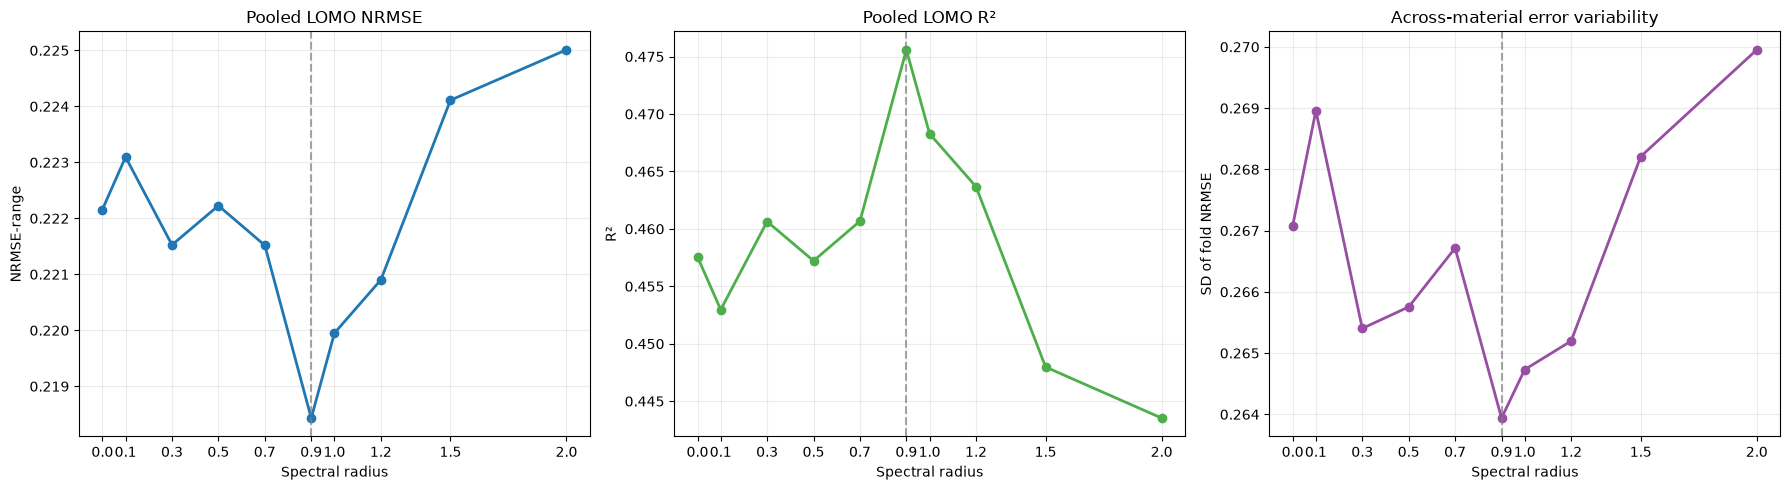

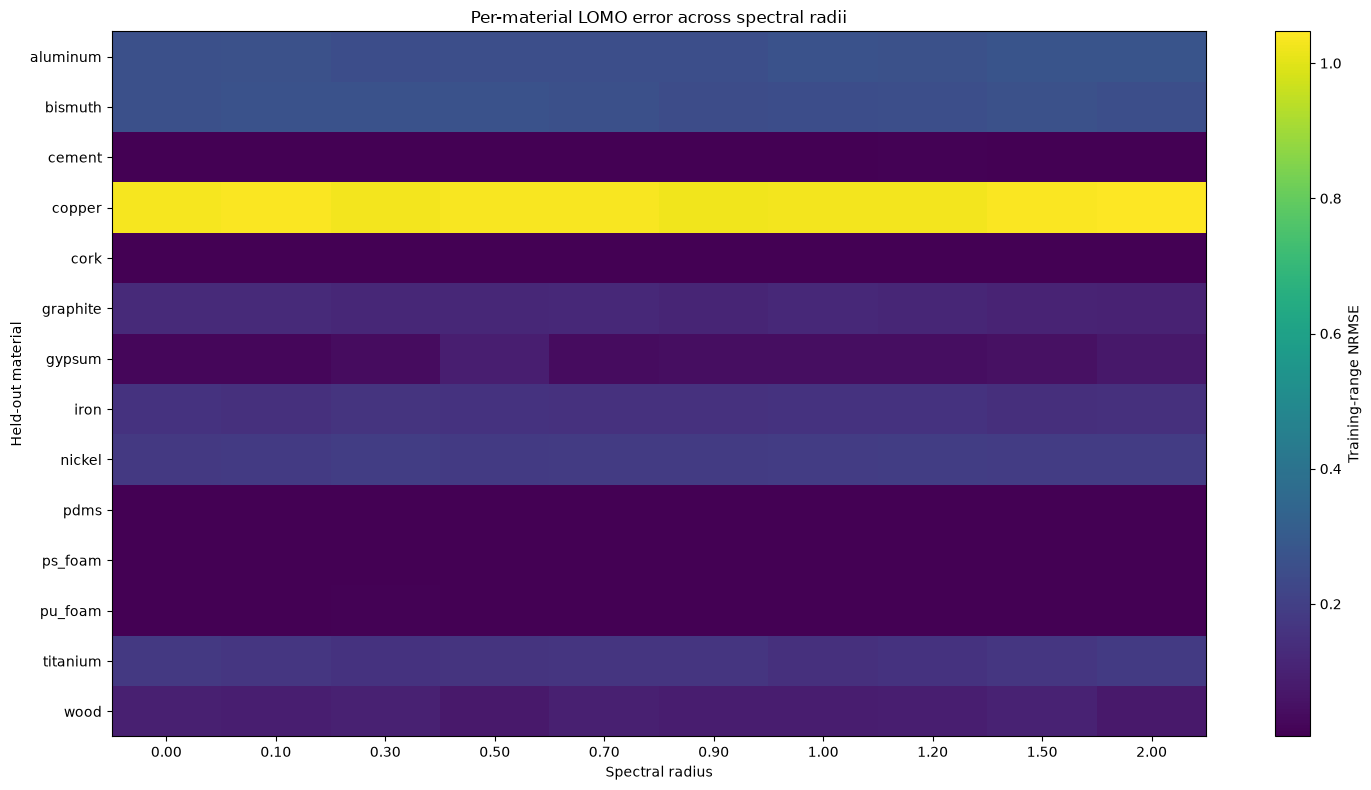

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(OVERALL["spectral_radius"], OVERALL["nrmse_range"], "o-", linewidth=2)
axes[0].set(title="Pooled LOMO NRMSE", ylabel="NRMSE-range")
axes[1].plot(OVERALL["spectral_radius"], OVERALL["r2"], "o-", color="#4daf4a", linewidth=2)
axes[1].set(title="Pooled LOMO R²", ylabel="R²")
axes[2].plot(OVERALL["spectral_radius"], OVERALL["fold_nrmse_sd"], "o-", color="#984ea3", linewidth=2)
axes[2].set(title="Across-material error variability", ylabel="SD of fold NRMSE")
for ax in axes:
    ax.set_xlabel("Spectral radius")
    ax.axvline(best["spectral_radius"], color="gray", linestyle="--", alpha=.7)
    ax.set_xticks(SPECTRAL_RADIUS_VALUES)
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

heatmap = FOLD_METRICS.pivot(
    index="held_out_material", columns="spectral_radius", values="nrmse_training_range"
)[list(SPECTRAL_RADIUS_VALUES)]
fig, ax = plt.subplots(figsize=(15, 8))
image = ax.imshow(heatmap, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(heatmap.columns)), [f"{x:.2f}" for x in heatmap.columns])
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set_xlabel("Spectral radius")
ax.set_ylabel("Held-out material")
ax.set_title("Per-material LOMO error across spectral radii")
fig.colorbar(image, ax=ax, label="Training-range NRMSE")
plt.tight_layout()
plt.show()


# 9. Prediction behavior for customizable case-study materials


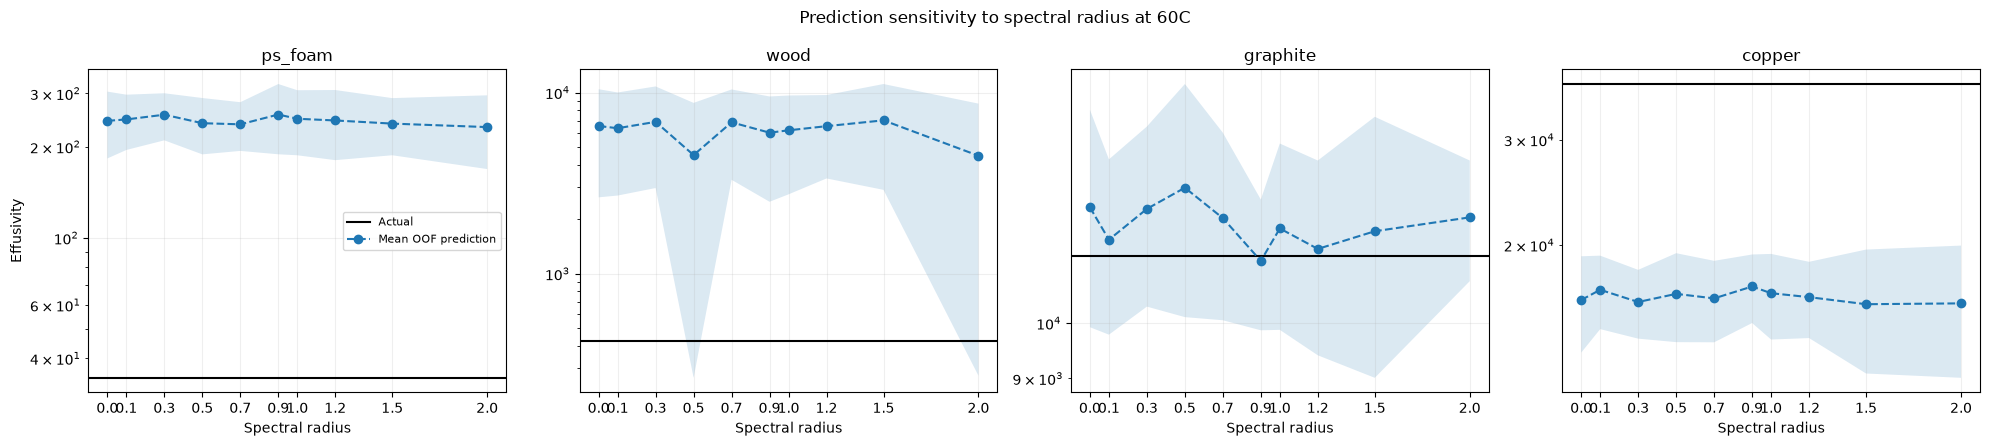

In [10]:
CASE_STUDY_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ["ps_foam", "wood", "graphite", "copper"]

case = (
    OOF[(OOF["Temperature"] == CASE_STUDY_TEMPERATURE) & OOF["Sample"].isin(CASE_STUDY_MATERIALS)]
    .groupby(["spectral_radius", "Sample"], as_index=False)
    .agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"), prediction_sd=("y_pred", "std"))
)

fig, axes = plt.subplots(1, len(CASE_STUDY_MATERIALS), figsize=(20, 4.5), sharex=True)
for ax, material in zip(axes, CASE_STUDY_MATERIALS):
    part = case[case["Sample"] == material].sort_values("spectral_radius")
    if part.empty:
        ax.set_visible(False)
        continue
    ax.axhline(part["y_true"].iloc[0], color="black", label="Actual")
    ax.plot(part["spectral_radius"], part["y_pred"], "o--", label="Mean OOF prediction")
    ax.fill_between(
        part["spectral_radius"], part["y_pred"] - part["prediction_sd"],
        part["y_pred"] + part["prediction_sd"], alpha=.16,
    )
    ax.set_yscale("log")
    ax.set_title(material)
    ax.set_xlabel("Spectral radius")
    ax.set_xticks(SPECTRAL_RADIUS_VALUES)
    ax.grid(alpha=.2)
axes[0].set_ylabel("Effusivity")
axes[0].legend(fontsize=8)
fig.suptitle(f"Prediction sensitivity to spectral radius at {CASE_STUDY_TEMPERATURE}")
plt.tight_layout()
plt.show()


# 10. Collective ESN dynamics across selected spectral radii


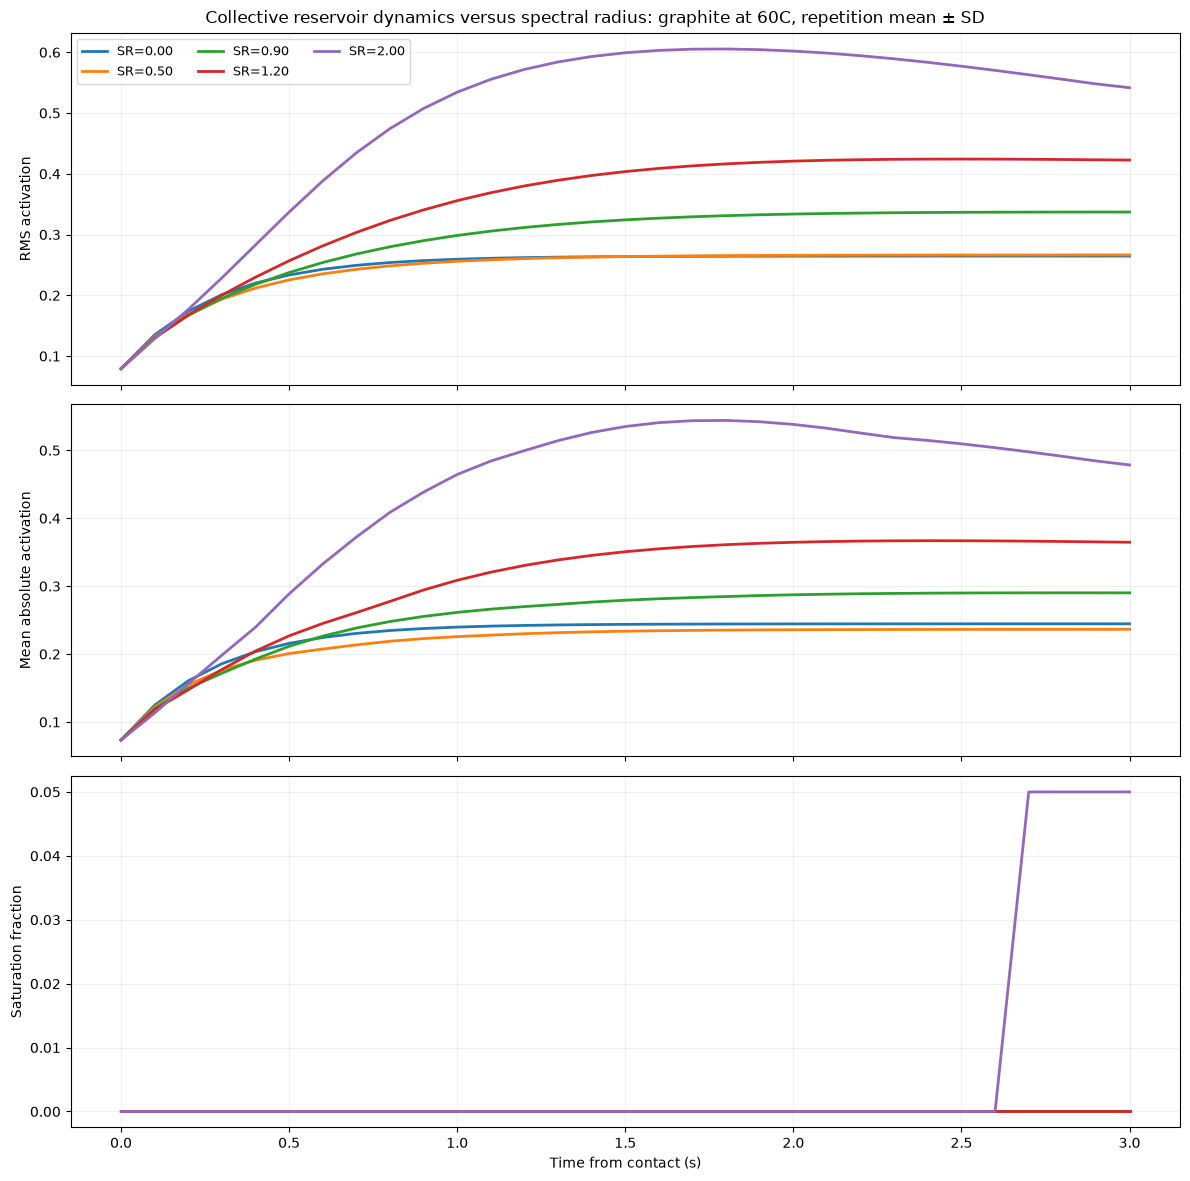

In [11]:
DYNAMICS_MATERIAL = "graphite"
DYNAMICS_TEMPERATURE = "60C"
DYNAMICS_SPECTRAL_RADII = (0.00, 0.50, 0.90, 1.20, 2.00)
DYNAMICS_SEED = 42

selected = METADATA[
    (METADATA["Sample"] == DYNAMICS_MATERIAL)
    & (METADATA["Temperature"] == DYNAMICS_TEMPERATURE)
].sort_values("Trial")
if selected.empty:
    raise KeyError("Requested dynamics material/temperature was not found.")

common_time = np.linspace(*ANALYSIS_WINDOW, 61)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for spectral_radius in DYNAMICS_SPECTRAL_RADII:
    if spectral_radius not in SPECTRAL_RADIUS_VALUES:
        raise KeyError(f"SR={spectral_radius} was not declared in SPECTRAL_RADIUS_VALUES.")
    reservoir = ManualReservoir(spectral_radius=spectral_radius, random_state=DYNAMICS_SEED)
    rms_trials, mean_abs_trials, saturation_trials = [], [], []
    for trial_id in selected["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        rms_trials.append(np.interp(common_time, state_time, np.sqrt(np.mean(states ** 2, axis=1))))
        mean_abs_trials.append(np.interp(common_time, state_time, np.mean(np.abs(states), axis=1)))
        saturation_trials.append(np.interp(common_time, state_time, np.mean(np.abs(states) >= .95, axis=1)))

    for ax, trials, label in zip(
        axes, (rms_trials, mean_abs_trials, saturation_trials),
        ("RMS activation", "Mean absolute activation", "Saturation fraction"),
    ):
        trials = np.asarray(trials)
        mean, sd = trials.mean(axis=0), trials.std(axis=0, ddof=1)
        ax.plot(common_time, mean, linewidth=2, label=f"SR={spectral_radius:.2f}")
        ax.fill_between(common_time, mean - sd, mean + sd, alpha=.10)
        ax.set_ylabel(label)
        ax.grid(alpha=.2)

axes[-1].set_xlabel("Time from contact (s)")
axes[0].legend(ncol=3, fontsize=9)
fig.suptitle(
    f"Collective reservoir dynamics versus spectral radius: {DYNAMICS_MATERIAL} at "
    f"{DYNAMICS_TEMPERATURE}, repetition mean ± SD"
)
plt.tight_layout()
plt.show()


# 11. Explicit spectral-radius → ESN-dynamics relationship

The same physical input is repeated across columns because only recurrent-weight
scaling changes. Reservoir size, leak rate, seed, input weights, and the underlying
unscaled recurrent matrix remain fixed, so matched unit indices can be compared.

The table reports state-step magnitude, lag-one persistence, and instantaneous
input–state coupling. Unlike leak rate, spectral radius is **not** a direct convex
weight between old and proposed states; it scales recurrent feedback inside tanh.


,spectral_radius,recurrent_scaling_factor,mean_state_step_magnitude,mean_lag1_state_correlation,mean_max_abs_input_state_correlation,mean_absolute_activation
0,0.0,0.0,0.002853,0.999851,0.940998,0.227236
1,0.5,0.5,0.003250,0.995039,0.880105,0.217152
2,0.9,0.9,0.004872,0.990921,0.881177,0.253802
3,1.2,1.2,0.006710,0.995355,0.942247,0.307295
4,2.0,2.0,0.013494,0.996899,0.902681,0.435068


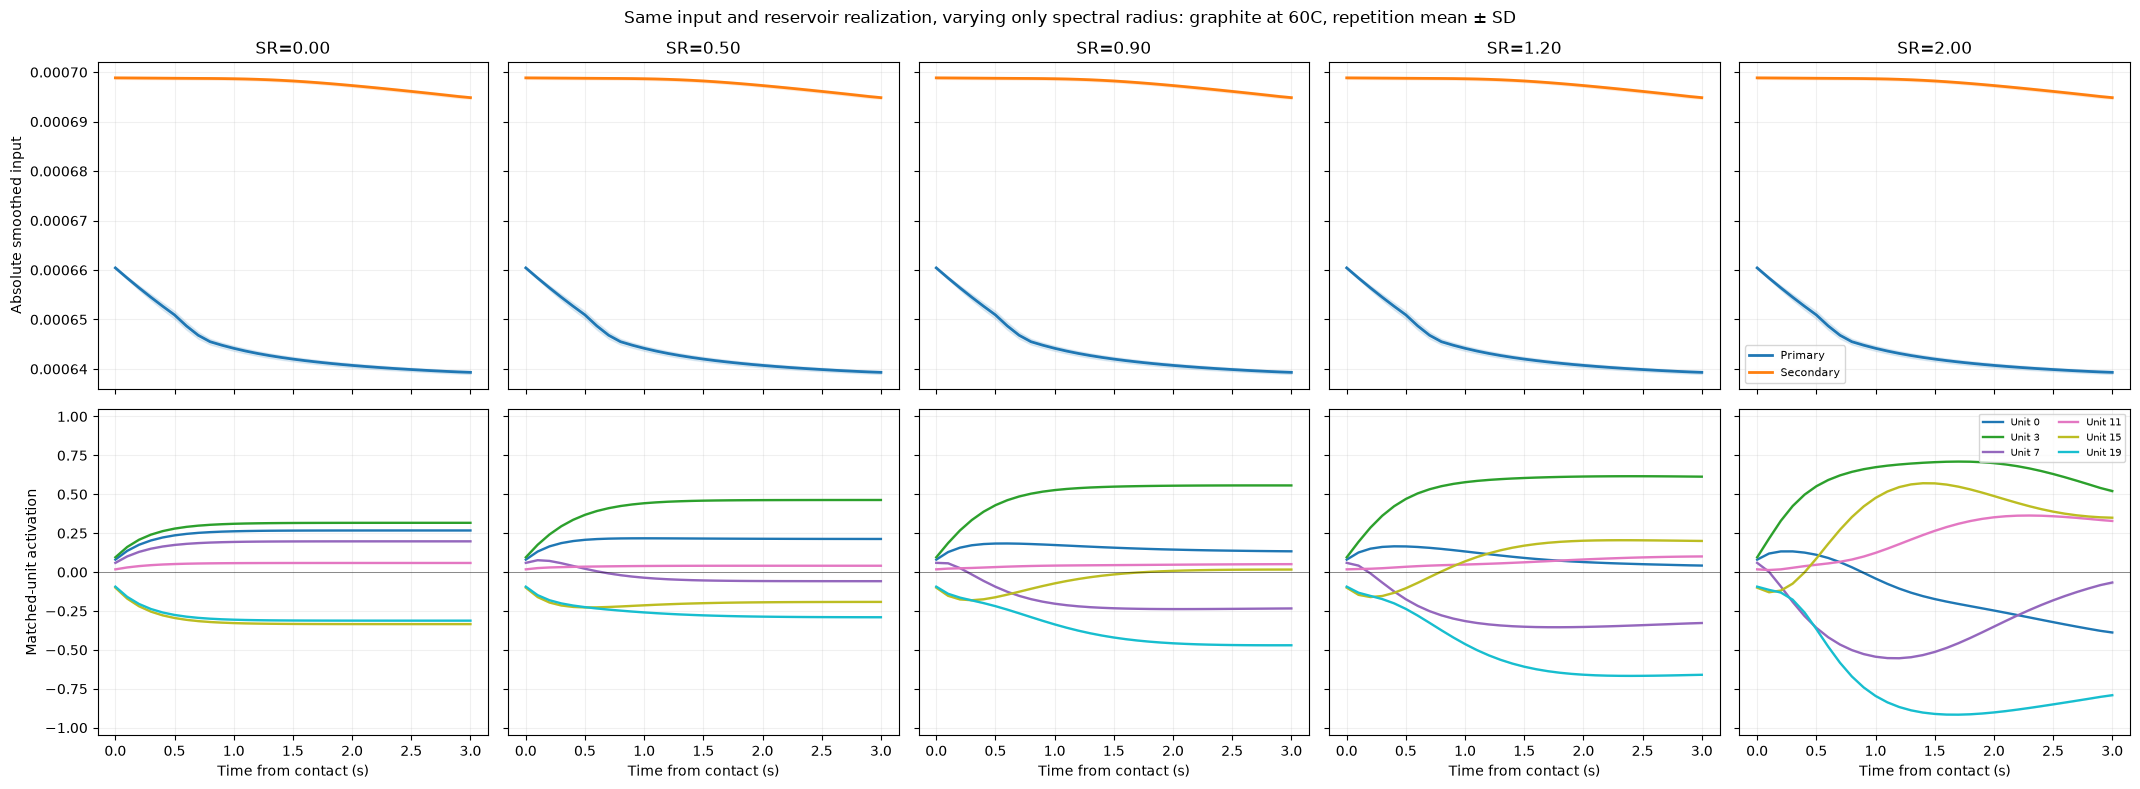

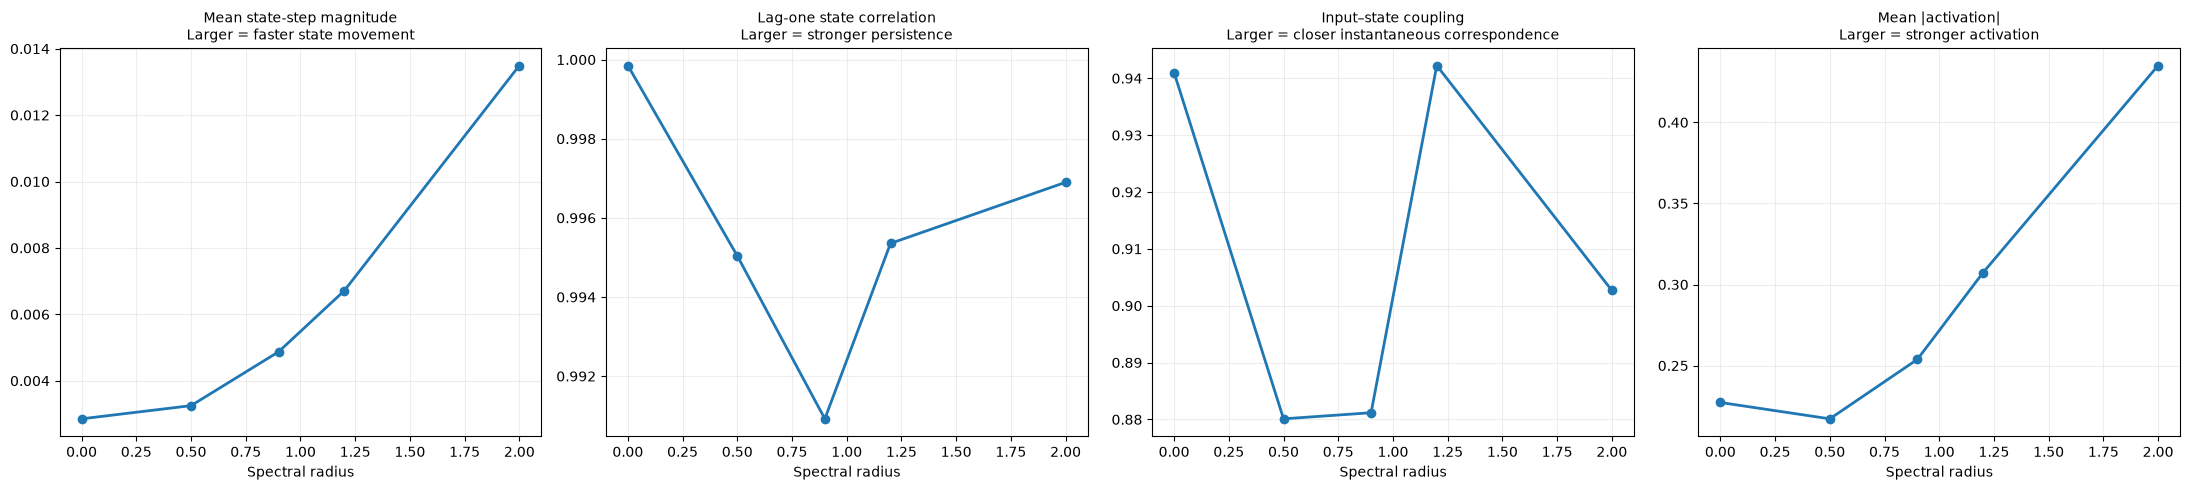

In [12]:
RELATIONSHIP_SPECTRAL_RADII = DYNAMICS_SPECTRAL_RADII
RELATIONSHIP_UNITS = (0, 3, 7, 11, 15, 19)

if any(unit >= FIXED_ESN_PARAMS["res_size"] for unit in RELATIONSHIP_UNITS):
    raise IndexError("RELATIONSHIP_UNITS contains an index outside the fixed reservoir.")


def resample_trial_input_and_states(trial_id, spectral_radius, seed, target_time):
    trial = aligned_trials[trial_id]
    time_values = trial["time_from_contact"].to_numpy(float)
    inputs = esn_input(trial)
    reservoir = ManualReservoir(spectral_radius=spectral_radius, random_state=seed)
    states = reservoir.run(inputs)
    state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
    input_resampled = np.column_stack([
        np.interp(target_time, time_values, inputs[:, channel])
        for channel in range(inputs.shape[1])
    ])
    state_resampled = np.column_stack([
        np.interp(target_time, state_time, states[:, unit])
        for unit in range(states.shape[1])
    ])
    return input_resampled, state_resampled


RELATIONSHIP_INPUT_CUBES, RELATIONSHIP_STATE_CUBES, relationship_rows = {}, {}, []
for spectral_radius in RELATIONSHIP_SPECTRAL_RADII:
    input_repetitions, state_repetitions = [], []
    for trial_id in selected["trial_id"]:
        inputs, states = resample_trial_input_and_states(
            trial_id, spectral_radius, DYNAMICS_SEED, common_time
        )
        input_repetitions.append(inputs); state_repetitions.append(states)
    input_cube, state_cube = np.asarray(input_repetitions), np.asarray(state_repetitions)
    RELATIONSHIP_INPUT_CUBES[spectral_radius] = input_cube
    RELATIONSHIP_STATE_CUBES[spectral_radius] = state_cube
    mean_inputs, mean_states = input_cube.mean(axis=0), state_cube.mean(axis=0)
    lag_correlations, couplings = [], []
    for unit in range(mean_states.shape[1]):
        previous, current = mean_states[:-1, unit], mean_states[1:, unit]
        if np.std(previous) > 1e-12 and np.std(current) > 1e-12:
            lag_correlations.append(float(np.corrcoef(previous, current)[0, 1]))
        channel_values = []
        for channel in range(mean_inputs.shape[1]):
            if np.std(mean_states[:, unit]) > 1e-12 and np.std(mean_inputs[:, channel]) > 1e-12:
                channel_values.append(abs(float(np.corrcoef(mean_inputs[:, channel], mean_states[:, unit])[0, 1])))
        if channel_values:
            couplings.append(max(channel_values))
    relationship_rows.append({
        "spectral_radius": float(spectral_radius),
        "recurrent_scaling_factor": float(spectral_radius),
        "mean_state_step_magnitude": float(np.mean(np.abs(np.diff(mean_states, axis=0)))),
        "mean_lag1_state_correlation": float(np.mean(lag_correlations)),
        "mean_max_abs_input_state_correlation": float(np.mean(couplings)),
        "mean_absolute_activation": float(np.mean(np.abs(state_cube))),
    })

SR_DYNAMICS_RELATIONSHIP = pd.DataFrame(relationship_rows)
display(SR_DYNAMICS_RELATIONSHIP)

fig, axes = plt.subplots(2, len(RELATIONSHIP_SPECTRAL_RADII), figsize=(4.3*len(RELATIONSHIP_SPECTRAL_RADII), 8), sharex=True, sharey="row")
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(RELATIONSHIP_UNITS)))
for column, spectral_radius in enumerate(RELATIONSHIP_SPECTRAL_RADII):
    input_cube = RELATIONSHIP_INPUT_CUBES[spectral_radius]
    state_cube = RELATIONSHIP_STATE_CUBES[spectral_radius]
    input_mean, input_sd = input_cube.mean(axis=0), input_cube.std(axis=0, ddof=1)
    state_mean, state_sd = state_cube.mean(axis=0), state_cube.std(axis=0, ddof=1)
    top, bottom = axes[0, column], axes[1, column]
    for channel, label, color in ((0, "Primary", "#1f77b4"), (1, "Secondary", "#ff7f0e")):
        top.plot(common_time, input_mean[:, channel], color=color, linewidth=2, label=label)
        top.fill_between(common_time, input_mean[:, channel]-input_sd[:, channel], input_mean[:, channel]+input_sd[:, channel], color=color, alpha=.12)
    top.set_title(f"SR={spectral_radius:.2f}")
    top.grid(alpha=.18)
    for color, unit in zip(unit_colors, RELATIONSHIP_UNITS):
        bottom.plot(common_time, state_mean[:, unit], color=color, linewidth=1.7, label=f"Unit {unit}")
        bottom.fill_between(common_time, state_mean[:, unit]-state_sd[:, unit], state_mean[:, unit]+state_sd[:, unit], color=color, alpha=.08)
    bottom.axhline(0, color="black", linewidth=.6, alpha=.5)
    bottom.set_ylim(-1.05, 1.05); bottom.set_xlabel("Time from contact (s)"); bottom.grid(alpha=.18)
axes[0, 0].set_ylabel("Absolute smoothed input")
axes[1, 0].set_ylabel("Matched-unit activation")
axes[0, -1].legend(fontsize=8); axes[1, -1].legend(fontsize=7, ncol=2)
fig.suptitle(f"Same input and reservoir realization, varying only spectral radius: {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}, repetition mean ± SD")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True)
diagnostics = (
    ("mean_state_step_magnitude", "Mean state-step magnitude", "Larger = faster state movement"),
    ("mean_lag1_state_correlation", "Lag-one state correlation", "Larger = stronger persistence"),
    ("mean_max_abs_input_state_correlation", "Input–state coupling", "Larger = closer instantaneous correspondence"),
    ("mean_absolute_activation", "Mean |activation|", "Larger = stronger activation"),
)
for ax, (column, title, subtitle) in zip(axes, diagnostics):
    ax.plot(SR_DYNAMICS_RELATIONSHIP["spectral_radius"], SR_DYNAMICS_RELATIONSHIP[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10); ax.set_xlabel("Spectral radius"); ax.grid(alpha=.22)
plt.tight_layout(); plt.show()


# 12. Unit-level trajectories, heatmaps, and dynamic-complexity diagnostics

Reservoir size, seed, input weights, and the underlying recurrent matrix are fixed;
only its spectral scaling changes. Corresponding unit indices can therefore be
followed across conditions. Each panel shows all 20 mean trajectories, mean-state
heatmaps, repetition-SD heatmaps, redundancy, effective rank, and saturation.


,spectral_radius,n_repetitions,mean_abs_unit_correlation,effective_rank,effective_rank_fraction,pca_dimensions_95pct,pca95_fraction_of_units,mean_unit_temporal_sd,mean_repetition_sd,saturation_fraction,mean_absolute_activation
0,0.0,6,1.000000,1.000000,0.050000,1,0.05,0.036372,0.000001,0.000000,0.227236
1,0.5,6,0.810046,1.243018,0.062151,2,0.10,0.043485,0.000002,0.000000,0.217152
2,0.9,6,0.690008,1.268008,0.063400,2,0.10,0.073731,0.000005,0.000000,0.253802
3,1.2,6,0.788453,1.250780,0.062539,2,0.10,0.107236,0.000017,0.000000,0.307295
4,2.0,6,0.661870,1.819458,0.090973,2,0.10,0.188647,0.000159,0.006557,0.435068


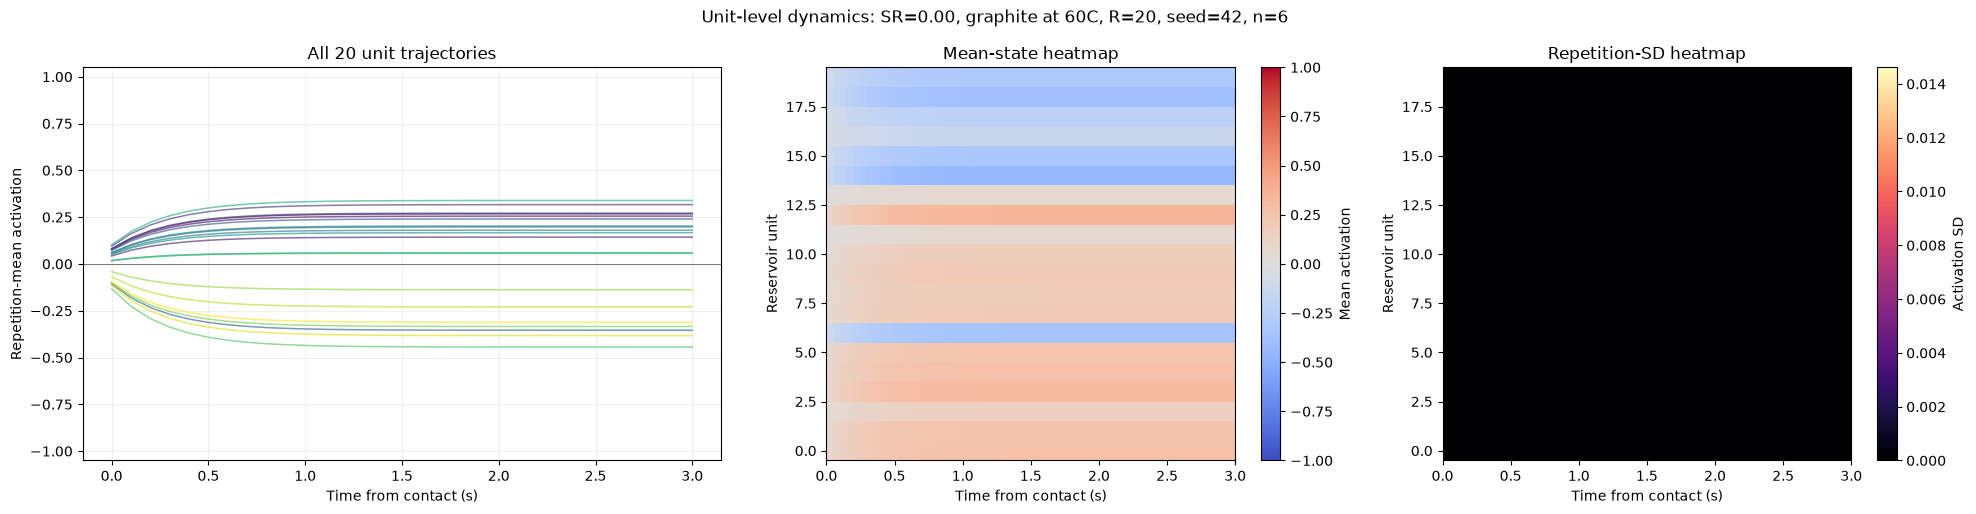

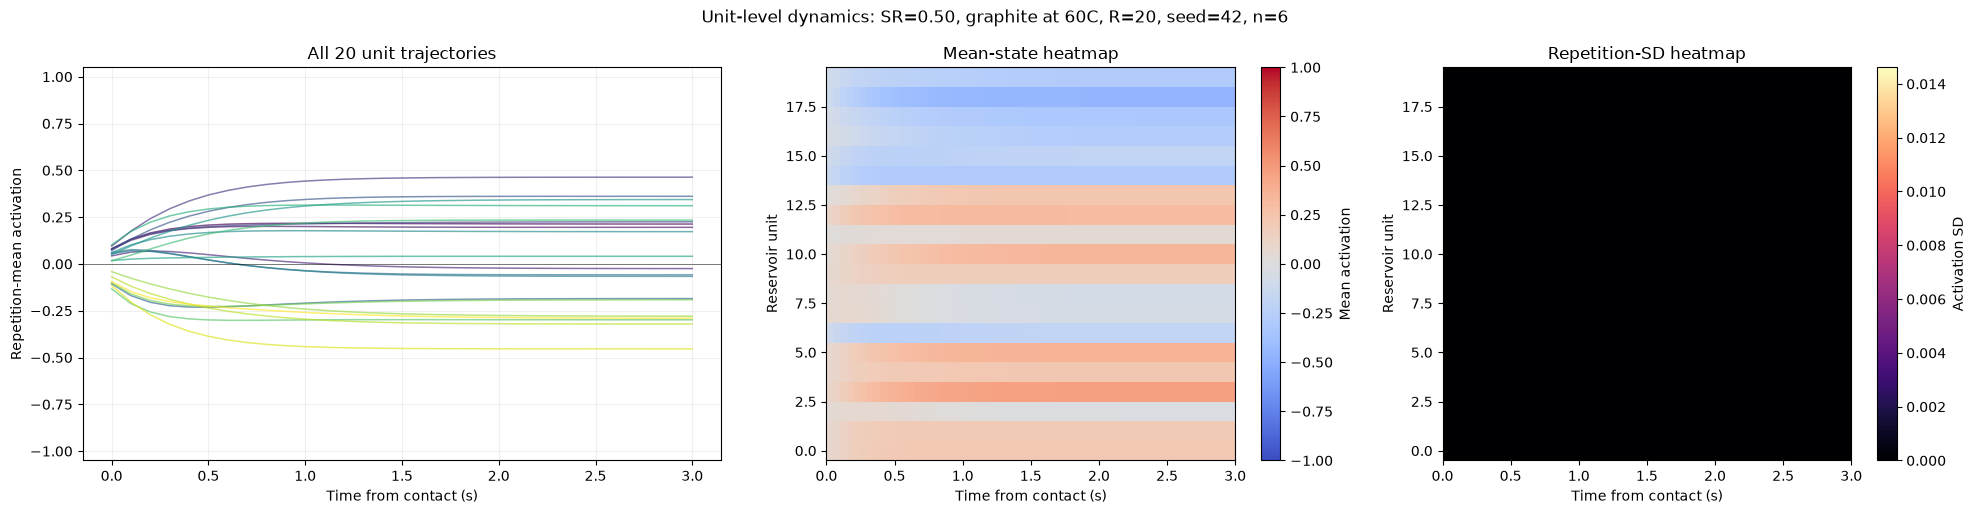

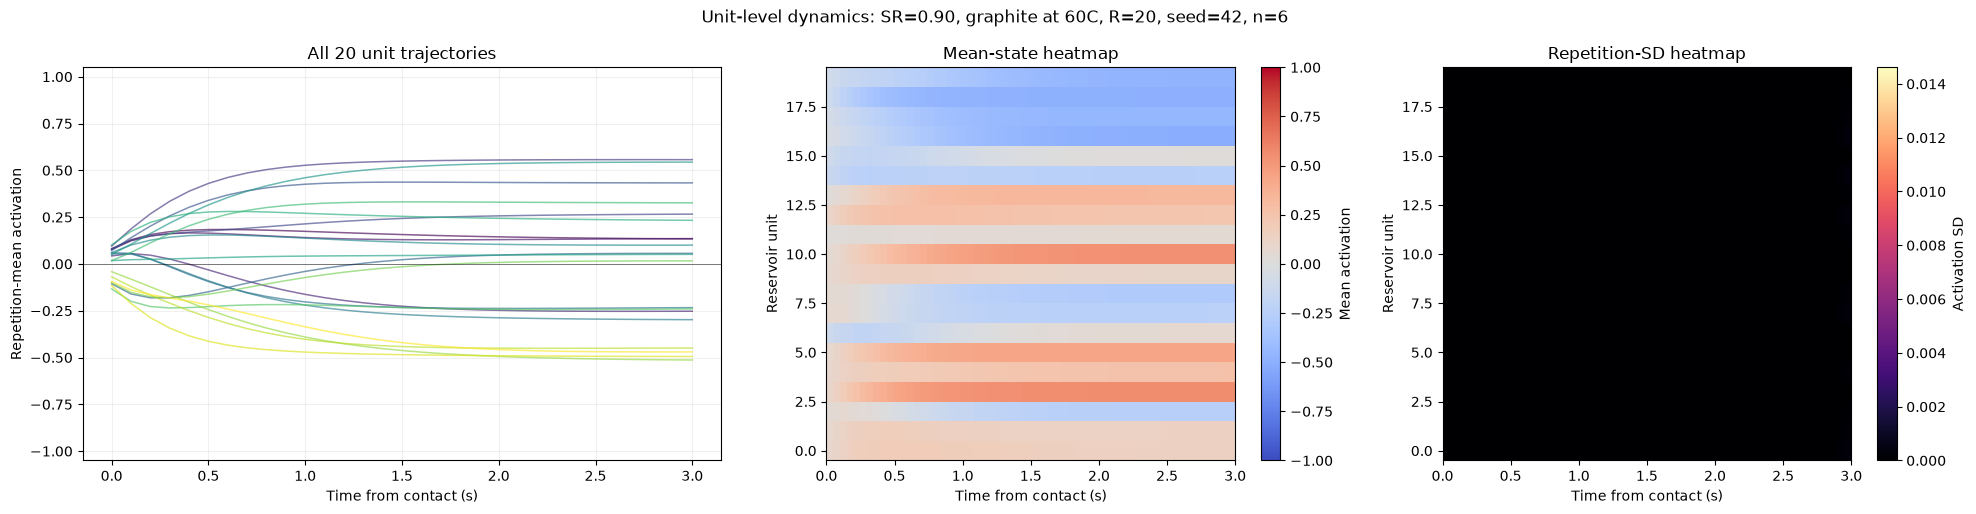

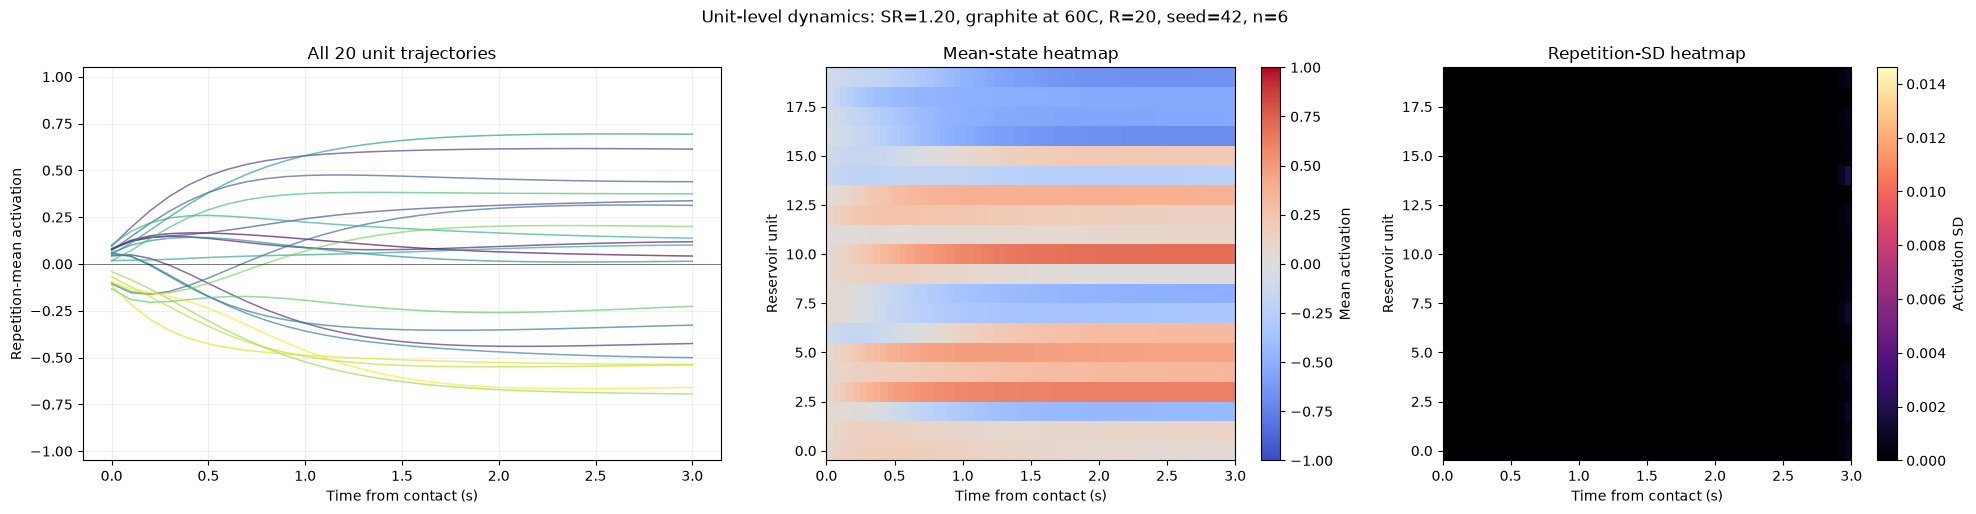

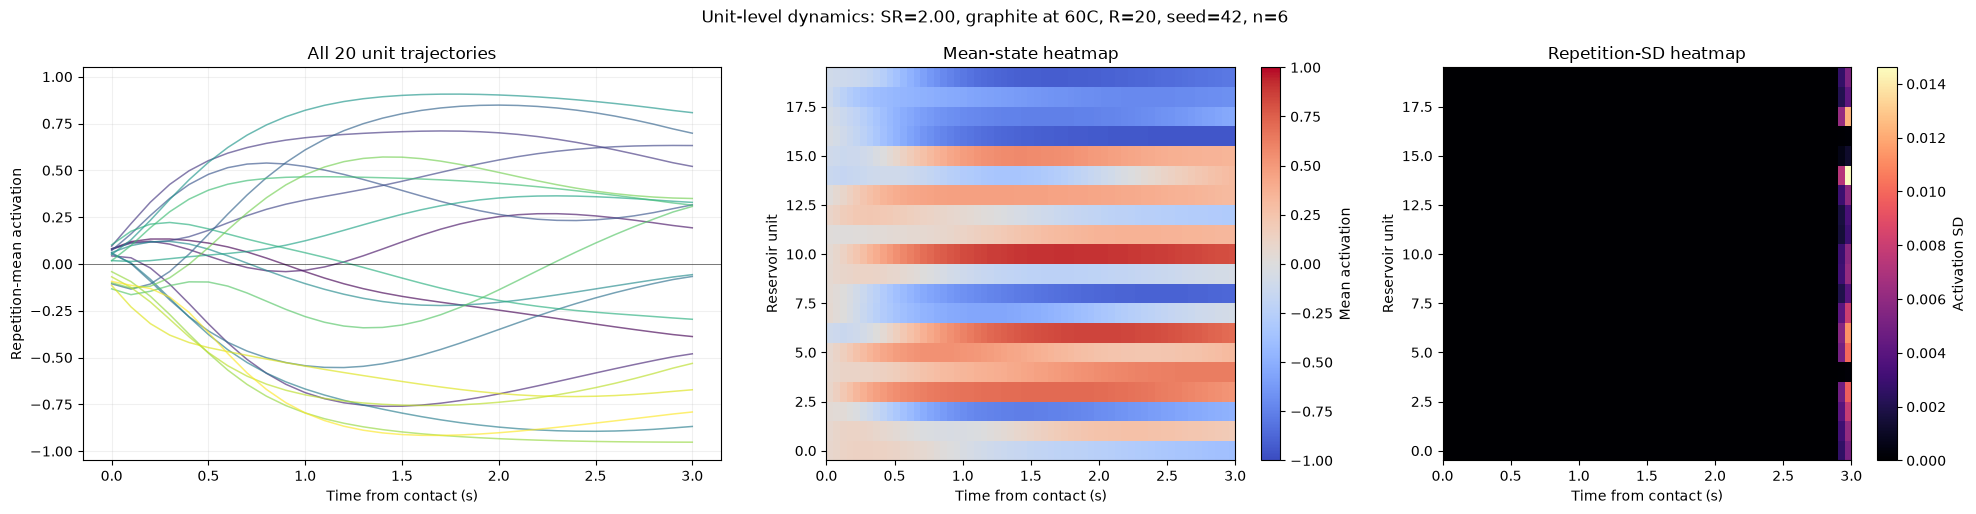

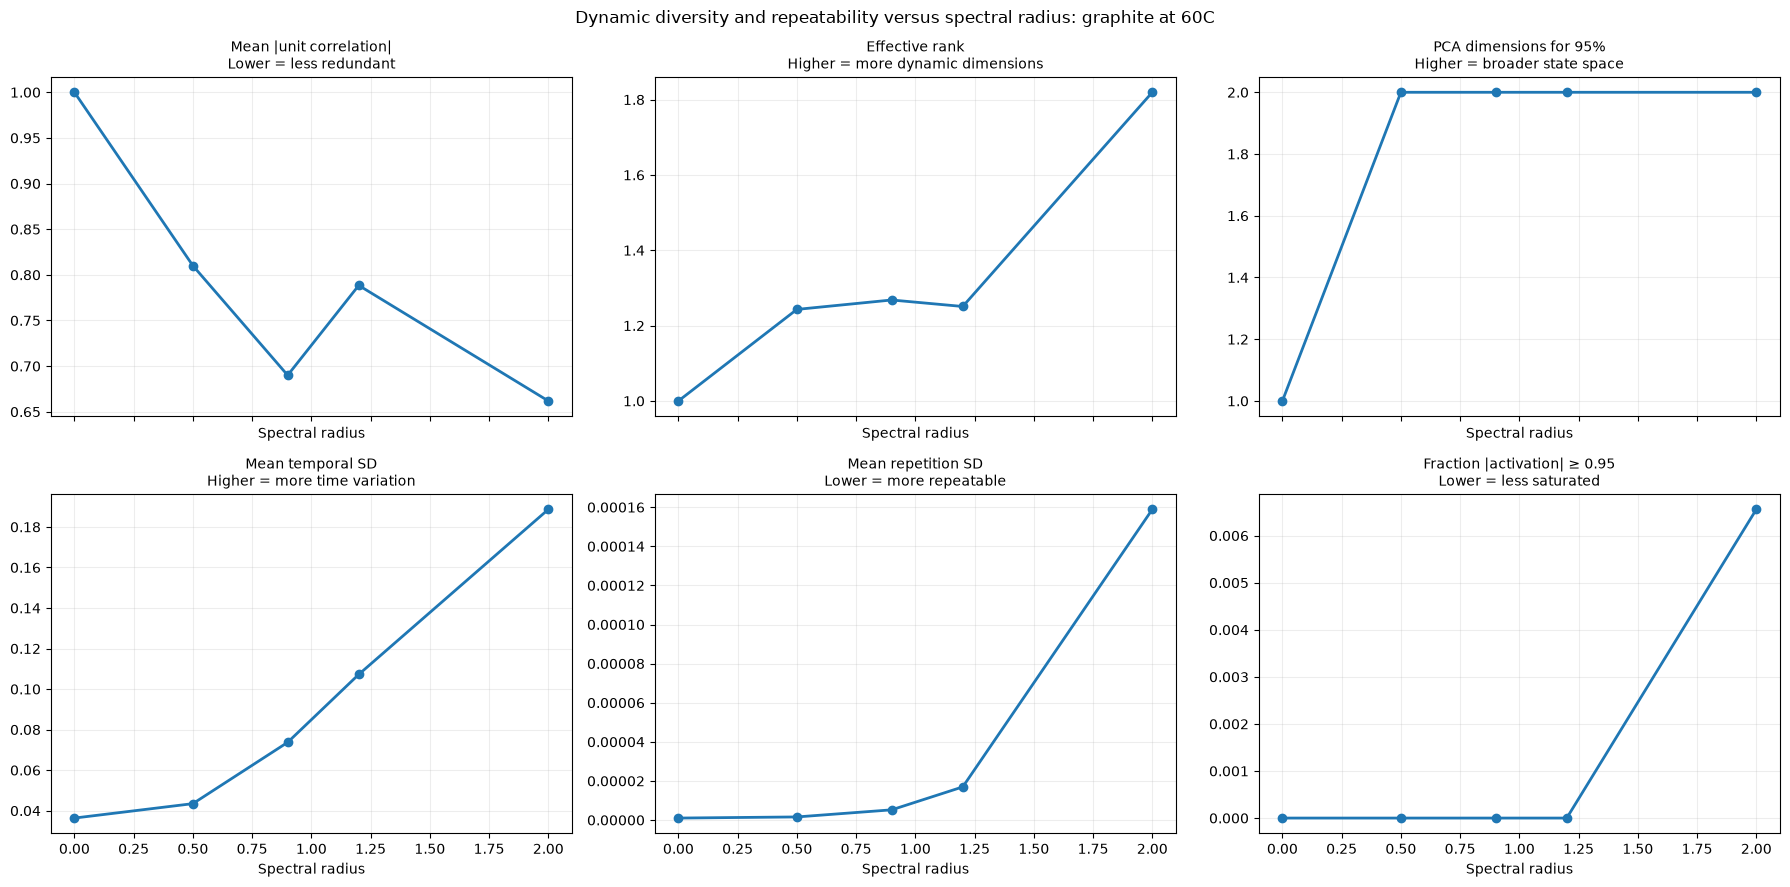

In [13]:
SATURATION_THRESHOLD = 0.95
PCA_VARIANCE_THRESHOLD = 0.95


def collect_resampled_states(spectral_radius, selected_metadata, seed, target_time):
    reservoir = ManualReservoir(spectral_radius=spectral_radius, random_state=seed)
    repetitions, trial_ids = [], []
    for trial_id in selected_metadata["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        repetitions.append(np.column_stack([
            np.interp(target_time, state_time, states[:, unit])
            for unit in range(states.shape[1])
        ]))
        trial_ids.append(trial_id)
    return np.asarray(repetitions), trial_ids


def state_complexity_metrics(state_cube, spectral_radius):
    state_cube = np.asarray(state_cube, float)
    repetition_mean = state_cube.mean(axis=0)
    centered = repetition_mean - repetition_mean.mean(axis=0, keepdims=True)
    valid = np.std(repetition_mean, axis=0) > 1e-12
    if valid.sum() >= 2:
        correlation = np.corrcoef(repetition_mean[:, valid], rowvar=False)
        off_diagonal = correlation[np.triu_indices_from(correlation, k=1)]
        mean_abs_correlation = float(np.nanmean(np.abs(off_diagonal)))
    else:
        mean_abs_correlation = np.nan
    singular_values = np.linalg.svd(centered, full_matrices=False, compute_uv=False)
    singular_values = singular_values[singular_values > 1e-12]
    if len(singular_values):
        energy_fraction = singular_values ** 2 / np.sum(singular_values ** 2)
        effective_rank = float(np.exp(-np.sum(energy_fraction * np.log(energy_fraction))))
        pca_dimensions_95 = int(np.searchsorted(np.cumsum(energy_fraction), PCA_VARIANCE_THRESHOLD) + 1)
    else:
        effective_rank, pca_dimensions_95 = 0.0, 0
    repetition_sd = state_cube.std(axis=0, ddof=1) if len(state_cube) > 1 else np.zeros_like(repetition_mean)
    return {
        "spectral_radius": float(spectral_radius), "n_repetitions": int(len(state_cube)),
        "mean_abs_unit_correlation": mean_abs_correlation,
        "effective_rank": effective_rank,
        "effective_rank_fraction": effective_rank / min(repetition_mean.shape),
        "pca_dimensions_95pct": pca_dimensions_95,
        "pca95_fraction_of_units": pca_dimensions_95 / FIXED_ESN_PARAMS["res_size"],
        "mean_unit_temporal_sd": float(np.mean(repetition_mean.std(axis=0, ddof=0))),
        "mean_repetition_sd": float(np.mean(repetition_sd)),
        "saturation_fraction": float(np.mean(np.abs(state_cube) >= SATURATION_THRESHOLD)),
        "mean_absolute_activation": float(np.mean(np.abs(state_cube))),
    }


UNIT_STATE_CUBES, UNIT_STATE_TRIAL_IDS, rows = {}, {}, []
for spectral_radius in DYNAMICS_SPECTRAL_RADII:
    cube, trial_ids = collect_resampled_states(spectral_radius, selected, DYNAMICS_SEED, common_time)
    UNIT_STATE_CUBES[spectral_radius] = cube
    UNIT_STATE_TRIAL_IDS[spectral_radius] = trial_ids
    rows.append(state_complexity_metrics(cube, spectral_radius))
DYNAMICS_COMPLEXITY = pd.DataFrame(rows)
display(DYNAMICS_COMPLEXITY)

all_sd = [cube.std(axis=0, ddof=1) for cube in UNIT_STATE_CUBES.values()]
sd_color_max = max(float(np.nanmax(x)) for x in all_sd)
if not np.isfinite(sd_color_max) or np.isclose(sd_color_max, 0):
    sd_color_max = 1.0

res_size = FIXED_ESN_PARAMS["res_size"]
for spectral_radius in DYNAMICS_SPECTRAL_RADII:
    cube = UNIT_STATE_CUBES[spectral_radius]
    mean_states = cube.mean(axis=0)
    sd_states = cube.std(axis=0, ddof=1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), gridspec_kw={"width_ratios": [1.25, 1, 1]})
    colors = plt.cm.viridis(np.linspace(0, 1, res_size))
    for unit in range(res_size):
        axes[0].plot(common_time, mean_states[:, unit], color=colors[unit], linewidth=1.1, alpha=.65)
    axes[0].axhline(0, color="black", linewidth=.7, alpha=.5)
    axes[0].set(title=f"All {res_size} unit trajectories", xlabel="Time from contact (s)", ylabel="Repetition-mean activation", ylim=(-1.05, 1.05))
    axes[0].grid(alpha=.18)
    im0 = axes[1].imshow(mean_states.T, aspect="auto", origin="lower", extent=[common_time[0], common_time[-1], -.5, res_size-.5], cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    axes[1].set(title="Mean-state heatmap", xlabel="Time from contact (s)", ylabel="Reservoir unit")
    fig.colorbar(im0, ax=axes[1], label="Mean activation")
    im1 = axes[2].imshow(sd_states.T, aspect="auto", origin="lower", extent=[common_time[0], common_time[-1], -.5, res_size-.5], cmap="magma", vmin=0, vmax=sd_color_max, interpolation="nearest")
    axes[2].set(title="Repetition-SD heatmap", xlabel="Time from contact (s)", ylabel="Reservoir unit")
    fig.colorbar(im1, ax=axes[2], label="Activation SD")
    fig.suptitle(f"Unit-level dynamics: SR={spectral_radius:.2f}, {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}, R={res_size}, seed={DYNAMICS_SEED}, n={len(cube)}")
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
diagnostics = (
    ("mean_abs_unit_correlation", "Mean |unit correlation|", "Lower = less redundant"),
    ("effective_rank", "Effective rank", "Higher = more dynamic dimensions"),
    ("pca_dimensions_95pct", "PCA dimensions for 95%", "Higher = broader state space"),
    ("mean_unit_temporal_sd", "Mean temporal SD", "Higher = more time variation"),
    ("mean_repetition_sd", "Mean repetition SD", "Lower = more repeatable"),
    ("saturation_fraction", "Fraction |activation| ≥ 0.95", "Lower = less saturated"),
)
for ax, (column, title, subtitle) in zip(axes.ravel(), diagnostics):
    ax.plot(DYNAMICS_COMPLEXITY["spectral_radius"], DYNAMICS_COMPLEXITY[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10); ax.set_xlabel("Spectral radius"); ax.grid(alpha=.22)
fig.suptitle(f"Dynamic diversity and repeatability versus spectral radius: {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}")
plt.tight_layout(); plt.show()


# 13. Save outputs and provenance


In [14]:
OVERALL_FILE = RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv"
FOLD_FILE = RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv"
OOF_FILE = RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv"
FEATURE_COUNT_FILE = RESULTS_DIR / f"{RESULT_STEM}_feature_counts.csv"
DYNAMICS_COMPLEXITY_FILE = RESULTS_DIR / f"{RESULT_STEM}_dynamics_complexity.csv"
SR_DYNAMICS_RELATIONSHIP_FILE = RESULTS_DIR / f"{RESULT_STEM}_sr_dynamics_relationship.csv"
PROVENANCE_FILE = RESULTS_DIR / f"{RESULT_STEM}_provenance.json"

OVERALL.to_csv(OVERALL_FILE, index=False)
FOLD_METRICS.to_csv(FOLD_FILE, index=False)
OOF.to_csv(OOF_FILE, index=False)
FEATURE_COUNTS.to_csv(FEATURE_COUNT_FILE, index=False)
DYNAMICS_COMPLEXITY.to_csv(DYNAMICS_COMPLEXITY_FILE, index=False)
SR_DYNAMICS_RELATIONSHIP.to_csv(SR_DYNAMICS_RELATIONSHIP_FILE, index=False)

provenance = {
    "purpose": "Controlled ESN spectral-radius ablation",
    "spectral_radii": list(SPECTRAL_RADIUS_VALUES),
    "temperature_folders": list(TEMPERATURE_FOLDERS),
    "target": TARGET, "analysis_window": list(ANALYSIS_WINDOW),
    "input_preprocessing": {
        "sensor_values": "absolute processed-file Primary and Secondary values",
        "smoothing": "Savitzky-Golay", "baseline_centering": False,
        "minmax_normalization": False, "standard_scaler": False,
        "esn_channels": ["Primary", "Secondary", "Primary-Secondary", "dPrimary/dt", "dSecondary/dt"],
    },
    "regressor_inputs": ["nine summarized statistics per ESN unit", "27 scalar thermal features"],
    "temperature_used_as_regressor_feature": False,
    "fixed_esn_parameters": FIXED_ESN_PARAMS,
    "xgb_parameters": XGB_PARAMS, "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold LOMO; 336 pooled OOF trial predictions per spectral radius",
    "unit_level_dynamics": {
        "material": DYNAMICS_MATERIAL, "temperature": DYNAMICS_TEMPERATURE,
        "spectral_radii": list(DYNAMICS_SPECTRAL_RADII), "seed": DYNAMICS_SEED,
        "common_time_points": len(common_time), "saturation_threshold": SATURATION_THRESHOLD,
        "pca_variance_threshold": PCA_VARIANCE_THRESHOLD,
        "unit_indices_matched_across_conditions": True,
        "relationship_units": list(RELATIONSHIP_UNITS),
        "relationship_metrics": [
            "mean_state_step_magnitude", "mean_lag1_state_correlation",
            "mean_max_abs_input_state_correlation",
        ],
    },
    "selection_warning": "The exploratory best spectral radius requires independent confirmation or nested selection.",
}
with PROVENANCE_FILE.open("w") as file:
    json.dump(provenance, file, indent=2)

print("Saved:")
for path in (OVERALL_FILE, FOLD_FILE, OOF_FILE, FEATURE_COUNT_FILE, DYNAMICS_COMPLEXITY_FILE,
    SR_DYNAMICS_RELATIONSHIP_FILE, PROVENANCE_FILE):
    print(" -", path)


Saved:
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_spectral_radius_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_overall_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_spectral_radius_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_fold_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_spectral_radius_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_oof_predictions.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Senso

# Interpretation checklist

- SR=0 removes recurrent feedback and provides an input-driven reference.
- Increasing SR strengthens recurrence and can extend memory or produce richer dynamics.
- Values above one are not automatically better; inspect saturation, redundancy, effective rank, and fold stability.
- Seek a region where pooled error improves without material-specific instability.
- Because the base recurrent matrix and seed are fixed, matched unit changes can be attributed to recurrent scaling.
- Treat the best spectral radius as exploratory unless independently confirmed or nested within validation.
